# **DESKRIPTOR AKUSTIK**

# Import Modules and Libraries

In [156]:
# Import library
# =======================================
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from matplotlib.gridspec import GridSpec
from scipy import stats
from matplotlib import gridspec
import matplotlib.image as mpimg


# Hasil Pengolahan Echoview

## Integration Results

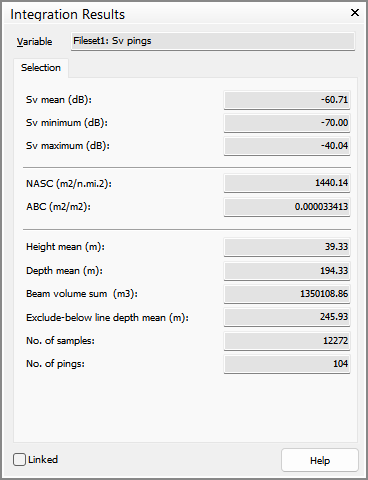

## Area Schooling
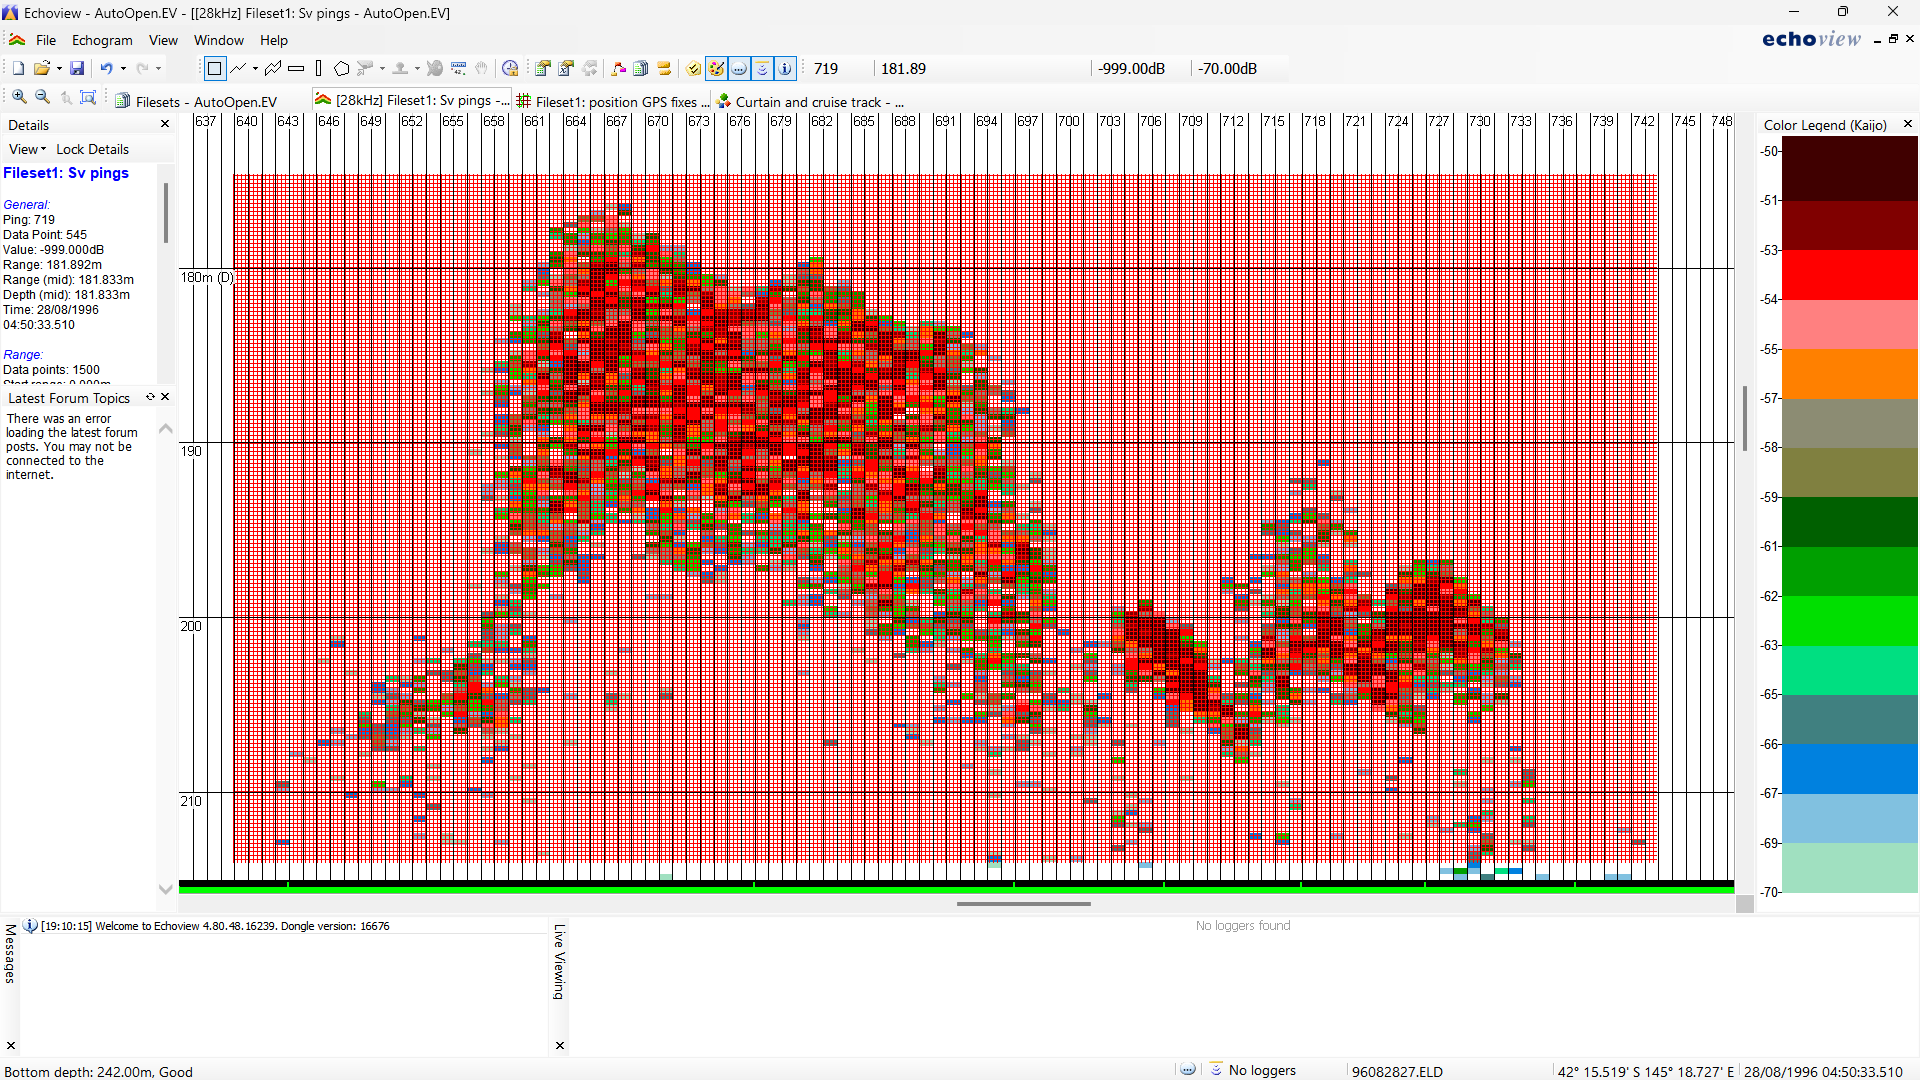

# Input Data 

input data integration result di atas ke sel di bawah secara manual

In [157]:
# Cell 2: data summary dari Integration Results (manual)
data_results = {
    "Sv mean (dB)": -60.71,
    "Sv min (dB)": -70.00,
    "Sv max (dB)": -40.04,
    "NASC (m2/n.mi.2)": 1440.14,
    "ABC (m2/m2)": 0.00033413,
    "Height mean (m)": 39.33,
    "Depth mean (m)": 194.33,
    "Beam volume sum (m3)": 1350108.86,
    "Exclude-below line depth mean (m)": 245.93,
    "No. of samples": 12272,
    "No. of pings": 104
}

for k, v in data_results.items():
    print(f"{k:25s}: {v}")

Sv mean (dB)             : -60.71
Sv min (dB)              : -70.0
Sv max (dB)              : -40.04
NASC (m2/n.mi.2)         : 1440.14
ABC (m2/m2)              : 0.00033413
Height mean (m)          : 39.33
Depth mean (m)           : 194.33
Beam volume sum (m3)     : 1350108.86
Exclude-below line depth mean (m): 245.93
No. of samples           : 12272
No. of pings             : 104


# Menghitung Deskriptor Akustik

## Deskriptor Energetik

In [158]:
# Data dari hasil integrasi
# ===============================
Sv_mean = data_results["Sv mean (dB)"]   # dB
Sv_min = data_results["Sv min (dB)"]    # dB
Sv_max = data_results["Sv max (dB)"]    # dB
n = data_results["No. of samples"]            # jumlah sampel

In [159]:
# 1. Deskriptor Energetik
# =========================

print("Deskriptor Energetik")

# Menentukan nilai
np.random.seed(42)
Sv = np.random.uniform(Sv_min, Sv_max, n)

# ===============================
# 1. Rata-rata Energi Akustik (dB)
# Konversi Sv (dB) ke energi linear Ei = 10^(Sv/10)
Ei = 10 ** (Sv / 10)

# Energi rata-rata linear
E_mean_linear = np.mean(Ei)

# Rata-rata Energi Akustik dalam dB
E_mean_dB = 10 * np.log10(E_mean_linear)

print(f"Rata-rata Energi Akustik (dB): {E_mean_dB:.2f}")

# ===============================
# 2. Simpangan Baku Energi (E_SD)
E_SD = np.sqrt(np.sum((Ei - E_mean_linear) ** 2) / (n - 1))
print(f"Simpangan Baku Energi (E_SD): {E_SD:.4e}")

# ===============================
# 3. Skewness

if n >= 3:
    numerator = n * np.sum((Ei - E_mean_linear) ** 3)
    denominator = (n - 1) * (n - 2) 
    skewness = numerator / denominator
else:
    skewness = 0
print(f"Skewness: {skewness:.4f}")

# ===============================
# 4. Kurtosis

if n >= 4:
    term1 = (n * (n + 1)) / ((n - 1) * (n - 2) * (n - 3))
    term2 = np.sum(((Ei - E_mean_linear) / E_SD) ** 4)
    term3 = (3 * (n - 1) ** 2) / ((n - 2) * (n - 3))
    kurtosis = term1 * term2 - term3
else:
    kurtosis = 0
print(f"Kurtosis: {kurtosis:.4f}")


Deskriptor Energetik
Rata-rata Energi Akustik (dB): -48.51
Simpangan Baku Energi (E_SD): 2.2252e-05
Skewness: 0.0000
Kurtosis: 3.1038


In [160]:
energetik = {
    "Rata-rata Energi Akustik (dB)": f"{E_mean_dB:.2f}",
    "Simpangan Baku Energi (E_SD)": f"{E_SD:.4e}",
    "Skewness": f"{skewness:.4f}",
    "Kurtosis": f"{kurtosis:.4f}"
}

## Deskriptor Morfometri

In [161]:
# Hitung Parameter Morfometri dari Data Integrasi
# ==========================================

# Asumsi (INI TERGANTUNG ALAT (CONTOH))
# --------------------------------------------
beam_width_m = 7.5     # lebar horizontal antar beam (m)
ping_spacing_m = 1.0  # jarak horizontal antar ping (m)

# Tinggi kawanan 
height = data_results["Height mean (m)"]
# Panjang kawanan
length = data_results["No. of pings"] * ping_spacing_m  # m
# Luas area (m²)
area = length * height
# Keliling (perimeter)
perimeter = 2 * (length + height)
# Elongasi (perbandingan panjang terhadap tinggi)
elongation = length / height

# ==========================================
# Dimensi fraktal (pendekatan empiris)
    # Rumus umum (Zakharia et al., 1996):
    # D = 2 * (log(perimeter/4) / log(area)**0.5)
    # tapi sering dipakai versi sederhana:
    # D = 2 * log(perimeter/4) / log(area)
if area > 0 and perimeter > 0:
    fractal_dim = 2 * math.log(perimeter / 4) / math.log(area)
else:
    fractal_dim = None
# ==========================================

print

# Hasil akhir
morfometri = {
    "Tinggi (m)": round(height, 2),
    "Panjang (m)": round(length, 2),
    "Area (m²)": round(area, 2),
    "Perimeter (m)": round(perimeter, 2),
    "Elongasi": round(elongation, 2),
    "Dimensi Fraktal": round(fractal_dim, 4) if fractal_dim else "Tidak dapat dihitung"
}

for k, v in morfometri.items():
    print(f"{k:25s}: {v}")


Tinggi (m)               : 39.33
Panjang (m)              : 104.0
Area (m²)                : 4090.32
Perimeter (m)            : 286.66
Elongasi                 : 2.64
Dimensi Fraktal          : 1.0274


## Deskriptor Batimetri

In [162]:
# Data dari hasil integrasi 
# ===============================
depth_mean = data_results["Depth mean (m)"]     
height_mean = data_results["Height mean (m)"]
exclude_below_depth = data_results["Exclude-below line depth mean (m)"]
n_samples = data_results["No. of samples"]

In [163]:
# Standar Deviasi dan distribusi normal
# ===============================
np.random.seed(42)
depth_samples = np.random.normal(depth_mean, 5, n_samples)  # variasi ±5 m

# ===============================
# 9. Rata-rata & Minimum kedalaman kawanan (m)
mean_depth = np.mean(depth_samples)
min_depth = np.min(depth_samples)

print(f"Rata-rata kedalaman kawanan (m): {mean_depth:.2f}")
print(f"Minimum kedalaman kawanan (m): {min_depth:.2f}")

# ===============================
# 10. Relative Altitude (%)
MinAlt = min_depth
MaxH = MinAlt + height_mean
Depth = exclude_below_depth

relative_altitude = ((MinAlt + MaxH) / 2) / Depth * 100
print(f"Relative Altitude (%): {relative_altitude:.2f}")


Rata-rata kedalaman kawanan (m): 194.31
Minimum kedalaman kawanan (m): 174.72
Relative Altitude (%): 79.04


In [164]:
batimetry = {
    "Rata-rata kedalaman kawanan (m)": f"{mean_depth:.2f}",
    "Minimum kedalaman kawanan (m)": f"{min_depth:.2f}",
    "Relative Altitude (%)": f"{relative_altitude:.2f}"
}

# Gabungan Deskriptor 


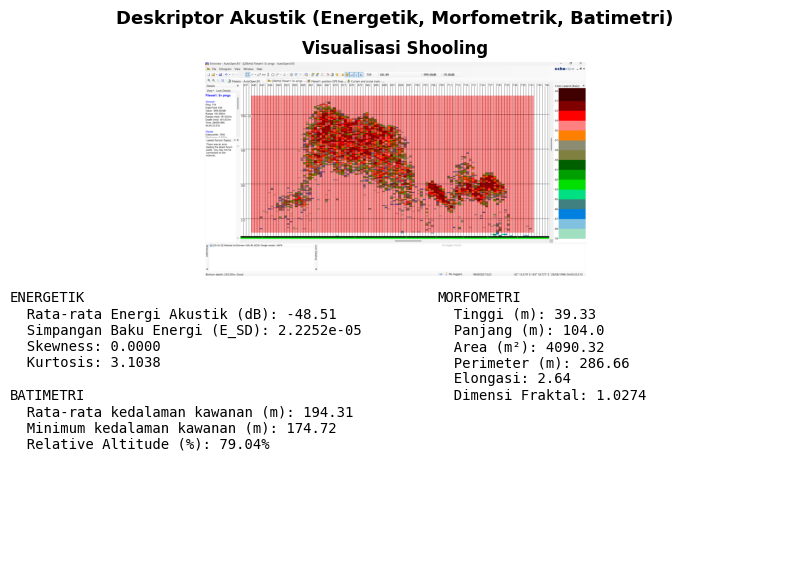

In [165]:
# 🔹 5. VISUALISASI REKAP DENGAN 1 GAMBAR DI ATAS TEKS
# ===============================

# ---- Layout figure ----
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 2], width_ratios=[1, 1])
fig.patch.set_facecolor("white")

# ---- ATAS: Gambar ----
ax_img = fig.add_subplot(gs[0, :])
ax_img.axis("off")

# ganti path sesuai lokasi file gambarmu
img = mpimg.imread("./area_result1.png")
ax_img.imshow(img)
ax_img.set_title("Visualisasi Shooling", fontsize=12, fontweight="bold")

# ---- KIRI: Energetik + Batimetri ----
ax_left = fig.add_subplot(gs[1, 0])
ax_left.axis("off")
left_text = [
    "ENERGETIK",
    f"  Rata-rata Energi Akustik (dB): {energetik['Rata-rata Energi Akustik (dB)']}",
    f"  Simpangan Baku Energi (E_SD): {energetik['Simpangan Baku Energi (E_SD)']}",
    f"  Skewness: {energetik['Skewness']}",
    f"  Kurtosis: {energetik['Kurtosis']}",
    "",
    "BATIMETRI",
    f"  Rata-rata kedalaman kawanan (m): {batimetry['Rata-rata kedalaman kawanan (m)']}",
    f"  Minimum kedalaman kawanan (m): {batimetry['Minimum kedalaman kawanan (m)']}",
    f"  Relative Altitude (%): {batimetry['Relative Altitude (%)']}%"
]
ax_left.text(0, 1, "\n".join(left_text), va="top", fontsize=10, family="monospace")

# ---- KANAN: Morfometri ----
ax_right = fig.add_subplot(gs[1, 1])
ax_right.axis("off")
right_text = [
    "MORFOMETRI",
    f"  Tinggi (m): {morfometri['Tinggi (m)']}",
    f"  Panjang (m): {morfometri['Panjang (m)']}",
    f"  Area (m²): {morfometri['Area (m²)']}",
    f"  Perimeter (m): {morfometri['Perimeter (m)']}",
    f"  Elongasi: {morfometri['Elongasi']}",
    f"  Dimensi Fraktal: {morfometri['Dimensi Fraktal']}"
]
ax_right.text(0, 1, "\n".join(right_text), va="top", fontsize=10, family="monospace")

plt.suptitle("Deskriptor Akustik (Energetik, Morfometrik, Batimetri)",
             fontsize=13, fontweight="bold", y=0.97)
plt.tight_layout()
plt.show()


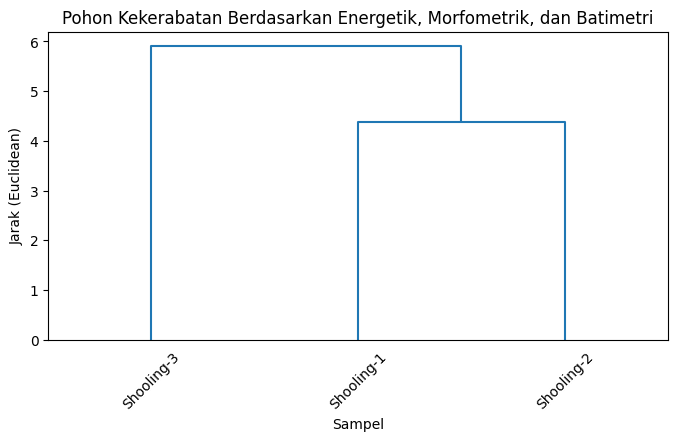

In [166]:
# Data gabungan (Data Contoh)
# =======================================
data = pd.DataFrame({
    'Energi_dB': [-51.14, -23.74, -50.29],
    'E_SD': [1.1217e-05, 9.1266e-05, 1.3981e-05],
    'Kurtosis': [2.5416, 7.2486, 2.2548],
    'Tinggi_m': [38, 32.67, 12.33],
    'Panjang_m': [42, 41, 20.0],
    'Area_m2': [1596, 1339.47, 246.1],
    'Elongasi': [1.11, 1.25, 1.62],
    'Mean_Depth': [190.7, 205.09, 227.78],
    'Rel_Altitude': [77.92, 70.81, 69.88]
})

# Beri label nama sampel biar dendrogram rapi
data.index = [f"Shooling-{i+1}" for i in range(len(data))]

# =======================================
# Standarisasi (biar semua skala sebanding)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# =======================================
# Hitung linkage matrix (misalnya metode ward)
Z = linkage(data_scaled, method='ward')

# =======================================
# Plot dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z, labels=data.index, leaf_rotation=45, leaf_font_size=10, color_threshold=0.7*max(Z[:,2]))
plt.title('Pohon Kekerabatan Berdasarkan Energetik, Morfometrik, dan Batimetri')
plt.xlabel('Sampel')
plt.ylabel('Jarak (Euclidean)')
plt.grid(False)
plt.show()
